<a href="https://colab.research.google.com/github/Chandini-M555/Data_Science_Task/blob/main/Trip_Pricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taxi Trip Pricing

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

# Data Preparation

In [42]:
df=pd.read_csv("/content/taxi_trip_pricing (1).csv")
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [43]:
df.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


# EDA

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [45]:
df.shape

(1000, 11)

In [46]:

df.drop_duplicates(inplace=True)
df.shape

(1000, 11)

In [47]:
df.isnull().sum()

,0
Trip_Distance_km,50
Time_of_Day,50
Day_of_Week,50
Passenger_Count,50
Traffic_Conditions,50
Weather,50
Base_Fare,50
Per_Km_Rate,50
Per_Minute_Rate,50
Trip_Duration_Minutes,50


In [48]:
#cleaning the data
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])

    elif df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].mean())

In [49]:
df.isnull().sum()

,0
Trip_Distance_km,0
Time_of_Day,0
Day_of_Week,0
Passenger_Count,0
Traffic_Conditions,0
Weather,0
Base_Fare,0
Per_Km_Rate,0
Per_Minute_Rate,0
Trip_Duration_Minutes,0


In [50]:
#Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [51]:
df.head()


,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,2,0,3.0,1,0,3.560000,0.80,0.32,53.82,36.262400
1,47.590000,0,0,1.0,0,0,3.502989,0.62,0.43,40.57,56.874773
2,36.870000,1,1,1.0,0,0,2.700000,1.21,0.15,37.27,52.903200
3,30.330000,1,0,4.0,1,0,3.480000,0.51,0.15,116.81,36.469800
4,27.070547,1,0,3.0,0,0,2.930000,0.63,0.32,22.64,15.618000


<Axes: xlabel='Trip_Price', ylabel='Count'>

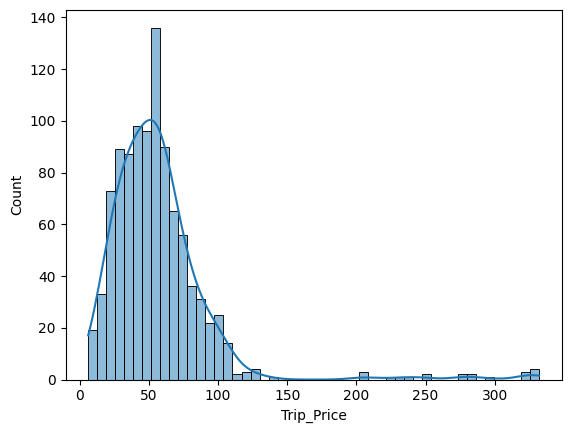

In [61]:
sns.histplot(x="Trip_Price",data=df,kde=True)

# Correlation

<Axes: >

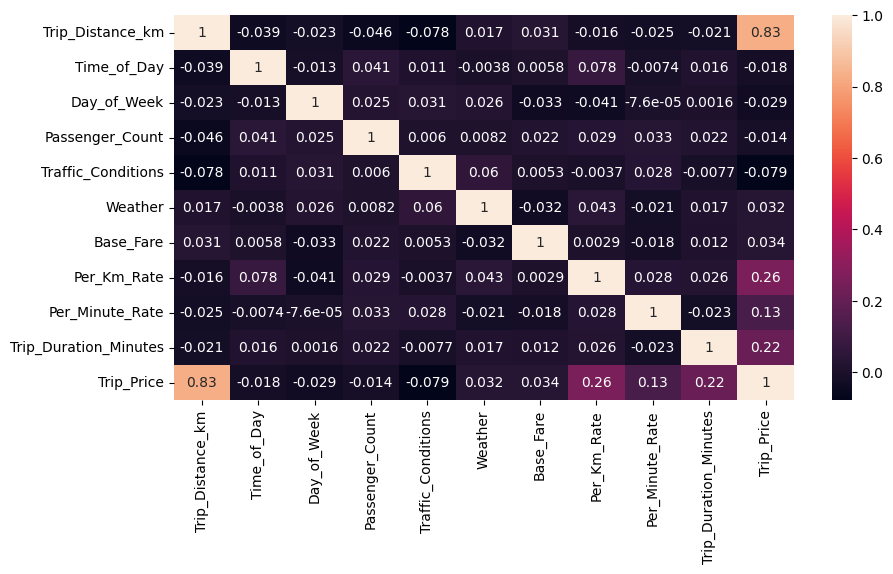

In [52]:
data=df.corr()
plt.figure(figsize=(10,5))
sns.heatmap(data,annot=True)

# Model Training

In [53]:
#Dividing input and output
X = df.drop('Trip_Price', axis=1)
Y = df['Trip_Price']


In [54]:
#splitting data into training and testing data
Xtrain,Xtest,Ytrain,Ytest=train_test_split(X,Y,test_size=0.3,random_state=42)

In [55]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
Xtrain=scaler.fit_transform(Xtrain)
Xtest=scaler.transform(Xtest)

In [56]:
model = LinearRegression()
model.fit(Xtrain, Ytrain)

LinearRegression()

# Model Prediction

In [57]:
y_pred = model.predict(Xtest)
y_pred


array([ 75.73415645,  87.91790572,  65.54347889,  73.05753936,
       118.20711395,  72.30911579,  24.4387527 ,  53.07256557,
        30.79708089,  77.15363765,  74.25684847, 100.94436688,
        74.1884712 ,  26.7375471 ,  -0.43862248,   5.25678968,
        69.65444246,  17.91981602,  22.29316494,  36.68786121,
        78.680496  ,  39.57655235, -24.82427857,  34.20836234,
        43.45665299,  91.61849827,  69.68195189,  43.66408556,
        35.10295088,  92.80102852,  83.62828631,  86.22966245,
        13.95390302, 104.88216805,  39.72219644,  95.45818851,
        23.154912  ,  58.54630031,  25.75311016,  76.54718735,
        51.65308442,  36.95535291,   0.73445402,  32.8623989 ,
        14.0636443 ,  60.54333662,  53.35195089,  45.24174492,
        43.0089822 ,  48.43051734,  63.50181153,   8.92445118,
        84.10107483,  61.03772428,  32.72836284,  69.96146224,
        36.7029903 ,  34.90145877,  60.54642211,  53.4373233 ,
        89.54104056,  71.97402251,  43.81548154,  54.98

# Model Evaluation

In [58]:
#calculating MAE,MSE and R2 score
print("MAE:", mean_absolute_error(Ytest, y_pred))
print("MSE:", mean_squared_error(Ytest, y_pred))
print("R2 Score:", r2_score(Ytest, y_pred))

MAE: 10.394292737413146
MSE: 290.0878977524591
R2 Score: 0.777132495615791


In [59]:
print("Training Eff: ",model.score(Xtrain,Ytrain))
print("Testing Eff: ",model.score(Xtest,Ytest))

Training Eff:  0.8538835616901412
Testing Eff:  0.777132495615791


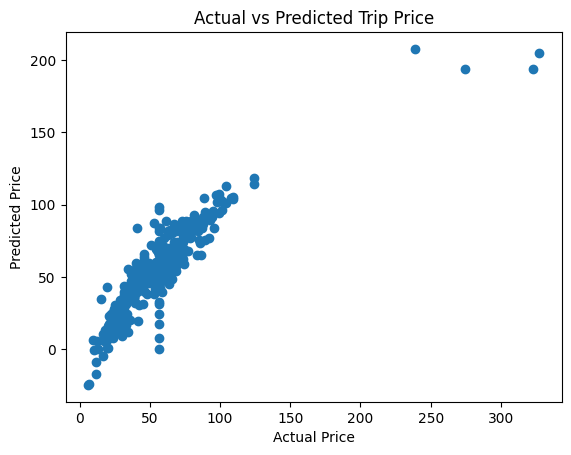

In [60]:
plt.scatter(Ytest, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Trip Price")
plt.show()